# Cinema Analytics DW — OLAP Insights

Visualizzazioni dei risultati delle 7 query OLAP sul Data Warehouse (Q1-Q6 + Q7 BONUS).
Tutte le query usano CTE di deduplicazione per evitare il bias da fan-out (vedi [README: DFM and Star Schema](../README.md#dfm-and-star-schema)).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

def find_project_root(start: Path) -> Path:
    start = Path(start).resolve()
    candidates = [start, *start.parents]
    try:
        candidates.extend(child for child in start.iterdir() if child.is_dir())
    except OSError:
        pass

    markers = (
        Path('notebooks/insights_plots.ipynb'),
        Path('scripts/run_olap.py'),
        Path('sql/olap_queries.sql'),
    )
    seen = set()
    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except OSError:
            continue
        if candidate in seen:
            continue
        seen.add(candidate)
        if all((candidate / marker).exists() for marker in markers):
            return candidate

    raise FileNotFoundError(f'Cinema Analytics project root not found from {start}')


sns.set_theme(style='whitegrid', palette='tab10')
PROJECT_ROOT = find_project_root(Path.cwd())
EXPORTS = PROJECT_ROOT / 'exports'
EXPORTS.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13


## Q1 — Revenue medio per GenreGroup per decade (ROLL-UP Time+Genre)
**Insight**: la cella seguente lo calcola programmaticamente dai risultati OLAP esportati, usando le stesse serie visualizzate nel grafico.

**Insight (calcolato dai risultati OLAP esportati)**: nella decade più recente (2010s), **Sci-Fi/Fantasy** guida il revenue medio con 220.44 M USD, seguito da **Action/Thriller** con 155.40 M USD; **Drama/Romance** raggiunge 54.81 M USD.

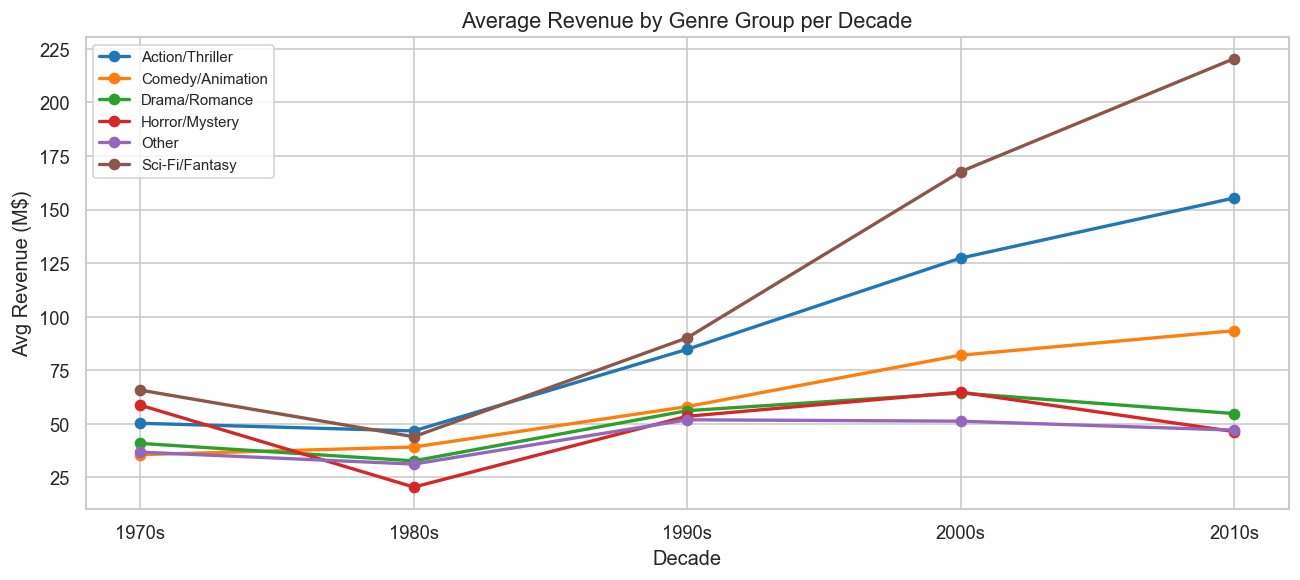

In [2]:
from IPython.display import Markdown, display

q1 = pd.read_csv(EXPORTS / 'q1_revenue_genre_decade.csv')
pivot = q1.pivot(index='decade', columns='genre_group', values='avg_revenue_m').fillna(0)

latest_decade_q1 = int(q1['decade'].max())
latest_q1 = q1.loc[q1['decade'].eq(latest_decade_q1)].sort_values('avg_revenue_m', ascending=False)
leader_q1, runner_up_q1 = latest_q1.iloc[:2].to_dict('records')
drama_q1 = latest_q1.loc[latest_q1['genre_group'].eq('Drama/Romance')].iloc[0]
display(Markdown(
    f"**Insight (calcolato dai risultati OLAP esportati)**: nella decade più recente ({latest_decade_q1}s), "
    f"**{leader_q1['genre_group']}** guida il revenue medio con {leader_q1['avg_revenue_m']:.2f} M USD, "
    f"seguito da **{runner_up_q1['genre_group']}** con {runner_up_q1['avg_revenue_m']:.2f} M USD; "
    f"**Drama/Romance** raggiunge {drama_q1['avg_revenue_m']:.2f} M USD."
))

fig, ax = plt.subplots(figsize=(11, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', linewidth=2, label=col)
ax.set_title('Average Revenue by Genre Group per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Avg Revenue (M$)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(pivot.index)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.tight_layout()
plt.savefig(EXPORTS / 'plot_q1_revenue_genre_decade.png', bbox_inches='tight')
plt.show()


## Q2 — Drill-down nel contesto di produzione del film (budget > $1M)
I tre livelli sono deduplicati separatamente. Il percorso `continent → production country → company context` è **non-strict**: una company può apparire sotto più paesi e il paese non ne indica il domicilio.

**Ramo selezionato per copertura**: **North America** (4,125 film; ROI medio 270.1%) → **United States of America** (4,063 film; ROI medio 272.5%) → **RKO Radio Pictures** (9 film; ROI medio 3,897.3%). Il leaf è una company nel contesto di produzione **United States of America**, non una dichiarazione di domicilio.

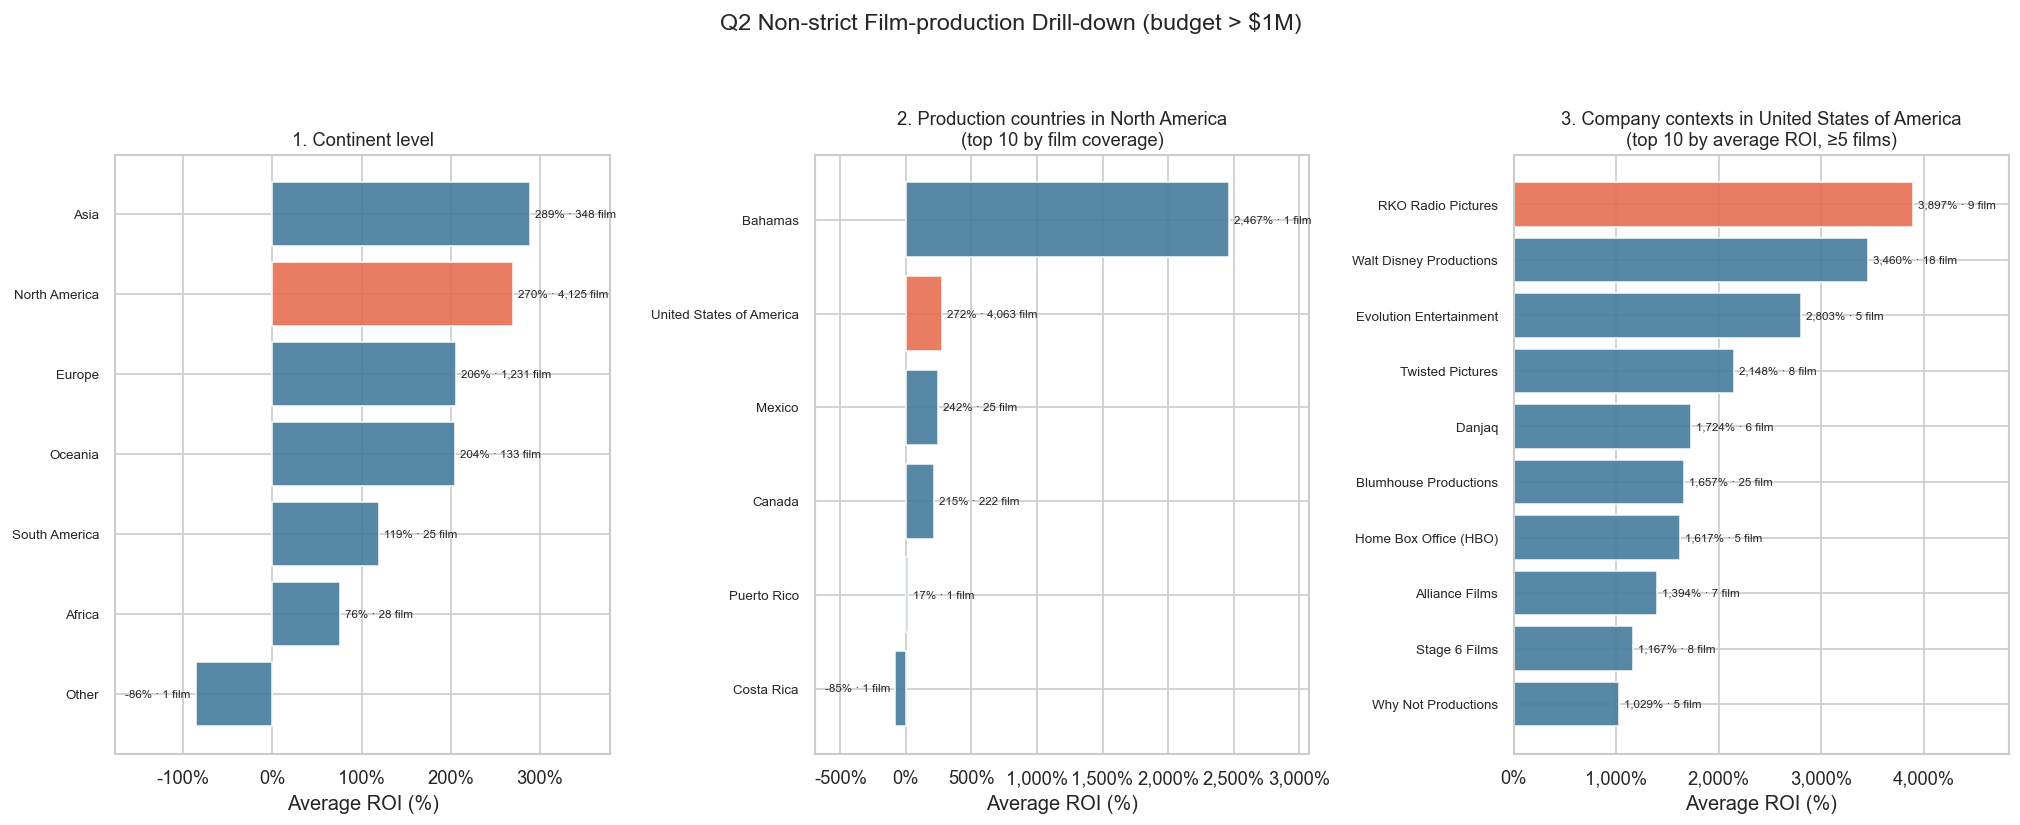

In [3]:
q2 = pd.read_csv(EXPORTS / 'q2_roi_production_drilldown.csv')
continents_q2 = q2.loc[q2['production_level'].eq('continent')].copy()
selected_continent_q2 = (
    continents_q2.sort_values(['num_films', 'continent'], ascending=[False, True])
    .iloc[0]['continent']
)
countries_q2 = q2.loc[
    q2['production_level'].eq('country') & q2['continent'].eq(selected_continent_q2)
].copy()
selected_country_q2 = (
    countries_q2.sort_values(['num_films', 'country_name'], ascending=[False, True])
    .iloc[0]['country_name']
)
companies_q2 = q2.loc[
    q2['production_level'].eq('company')
    & q2['continent'].eq(selected_continent_q2)
    & q2['country_name'].eq(selected_country_q2)
].copy()
leader_company_q2 = (
    companies_q2.sort_values(
        ['avg_roi_pct', 'num_films', 'company_name'], ascending=[False, False, True]
    ).iloc[0]
)

continent_row_q2 = continents_q2.loc[
    continents_q2['continent'].eq(selected_continent_q2)
].iloc[0]
country_row_q2 = countries_q2.loc[
    countries_q2['country_name'].eq(selected_country_q2)
].iloc[0]
display(Markdown(
    f"**Ramo selezionato per copertura**: **{selected_continent_q2}** "
    f"({int(continent_row_q2['num_films']):,} film; ROI medio {continent_row_q2['avg_roi_pct']:,.1f}%) → "
    f"**{selected_country_q2}** ({int(country_row_q2['num_films']):,} film; "
    f"ROI medio {country_row_q2['avg_roi_pct']:,.1f}%) → **{leader_company_q2['company_name']}** "
    f"({int(leader_company_q2['num_films']):,} film; ROI medio "
    f"{leader_company_q2['avg_roi_pct']:,.1f}%). Il leaf è una company nel contesto di "
    f"produzione **{selected_country_q2}**, non una dichiarazione di domicilio."
))

continents_plot_q2 = continents_q2.sort_values('avg_roi_pct')
countries_plot_q2 = countries_q2.nlargest(10, 'num_films').sort_values('avg_roi_pct')
companies_plot_q2 = (
    companies_q2.sort_values(
        ['avg_roi_pct', 'num_films', 'company_name'], ascending=[False, False, True]
    ).head(10).sort_values('avg_roi_pct')
)

def _short_q2_label(value, width=29):
    value = str(value)
    return value if len(value) <= width else value[:width - 3] + '...'


def _plot_q2_level(ax, frame, label_col, title, highlight):
    labels = [_short_q2_label(value) for value in frame[label_col]]
    colors = ['#E76F51' if value == highlight else '#457B9D' for value in frame[label_col]]
    bars = ax.barh(labels, frame['avg_roi_pct'], color=colors, alpha=0.9)
    ax.bar_label(
        bars,
        labels=[f"{roi:,.0f}% · {int(films):,} film"
                for roi, films in zip(frame['avg_roi_pct'], frame['num_films'])],
        padding=3, fontsize=7
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Average ROI (%)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value:,.0f}%'))
    ax.tick_params(axis='y', labelsize=8)
    ax.margins(x=0.24)


fig, axes_q2 = plt.subplots(1, 3, figsize=(17, 7))
_plot_q2_level(
    axes_q2[0], continents_plot_q2, 'continent', '1. Continent level', selected_continent_q2
)
_plot_q2_level(
    axes_q2[1], countries_plot_q2, 'country_name',
    f'2. Production countries in {selected_continent_q2}\n(top 10 by film coverage)',
    selected_country_q2
)
_plot_q2_level(
    axes_q2[2], companies_plot_q2, 'company_name',
    f'3. Company contexts in {selected_country_q2}\n(top 10 by average ROI, ≥5 films)',
    leader_company_q2['company_name']
)
fig.suptitle('Q2 Non-strict Film-production Drill-down (budget > $1M)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(EXPORTS / 'plot_q2_roi_production_drilldown.png', bbox_inches='tight')
plt.show()


## Q3 — Rating per Era e Language Family (DICE)
**Insight (risultati OLAP)**: Koreanic è presente in Modern (rating medio 6,70; 261 film), mentre non ha una riga Blockbuster Era che superi la soglia di significatività di 20 film. Il grafico mantiene quindi Koreanic e segnala esplicitamente il dato mancante, invece di eliminarlo.

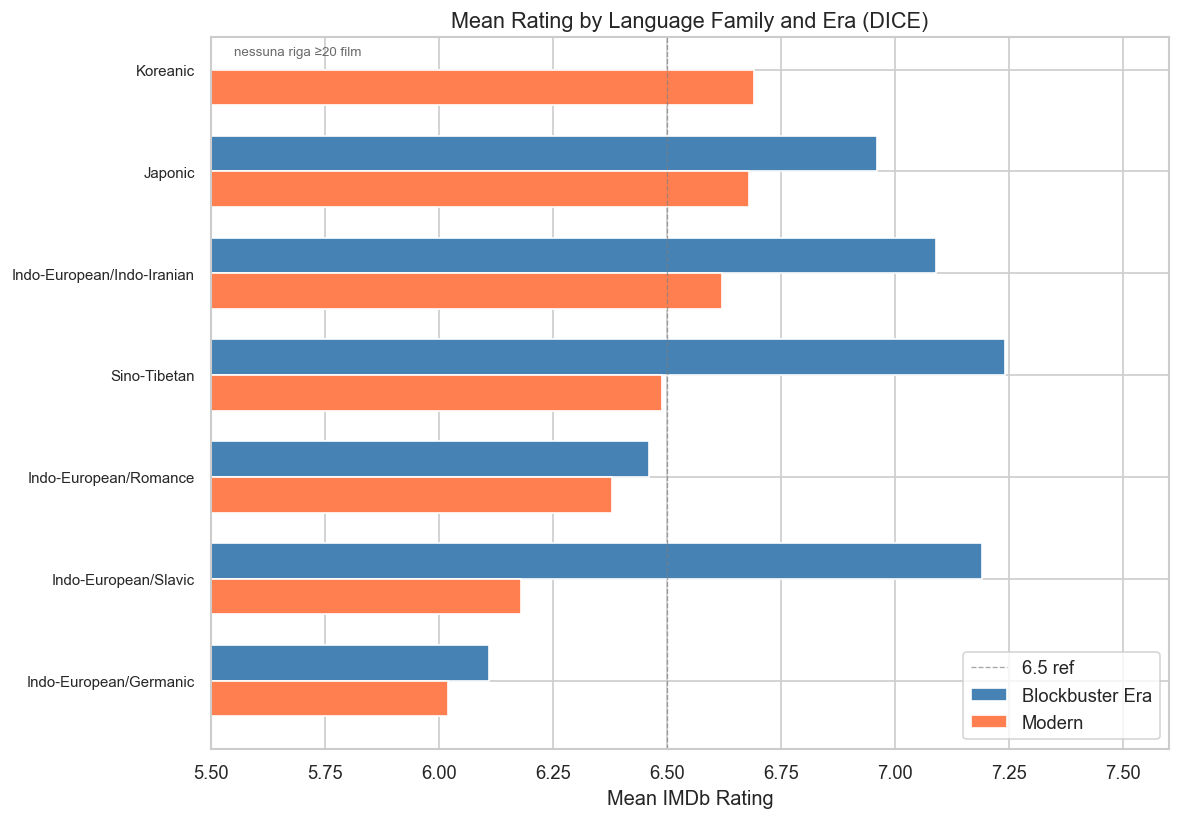

In [4]:
q3 = pd.read_csv(EXPORTS / 'q3_rating_era_language_family.csv')
pivot3 = q3.pivot(index='language_family', columns='era', values='mean_rating')
pivot3 = pivot3.sort_values('Modern', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
x = range(len(pivot3))
width = 0.35
cols = list(pivot3.columns)
offsets = [width/2, -width/2]
colors = ['steelblue', 'coral']
for era, offset, color in zip(cols, offsets, colors):
    values = pivot3[era]
    ax.barh([i + offset for i in x], values, width, label=era, color=color)
    for i, value in enumerate(values):
        if pd.isna(value):
            ax.text(5.55, i + offset, 'no rows ≥ 20 films', va='center', fontsize=8, color='dimgray')
ax.set_yticks(list(x))
ax.set_yticklabels(pivot3.index, fontsize=9)
ax.set_xlabel('Mean IMDb Rating')
ax.set_title('Mean Rating by Language Family and Era (DICE)')
ax.set_xlim(5.5, 7.6)
ax.axvline(6.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='6.5 ref')
ax.legend()
plt.tight_layout()
plt.savefig(EXPORTS / 'plot_q3_rating_era_language.png', bbox_inches='tight')
plt.show()


## Q4 — ROI per dimensione studio (SLICE + CTE)
**Insight (risultati OLAP)**: gli studi piccoli (<10 film) hanno il ROI medio più alto (548,00%), seguiti dai medi (491,18%) e dai grandi (393,43%). Il grafico mostra anche che il budget medio non cresce in modo monotono con la dimensione dello studio.

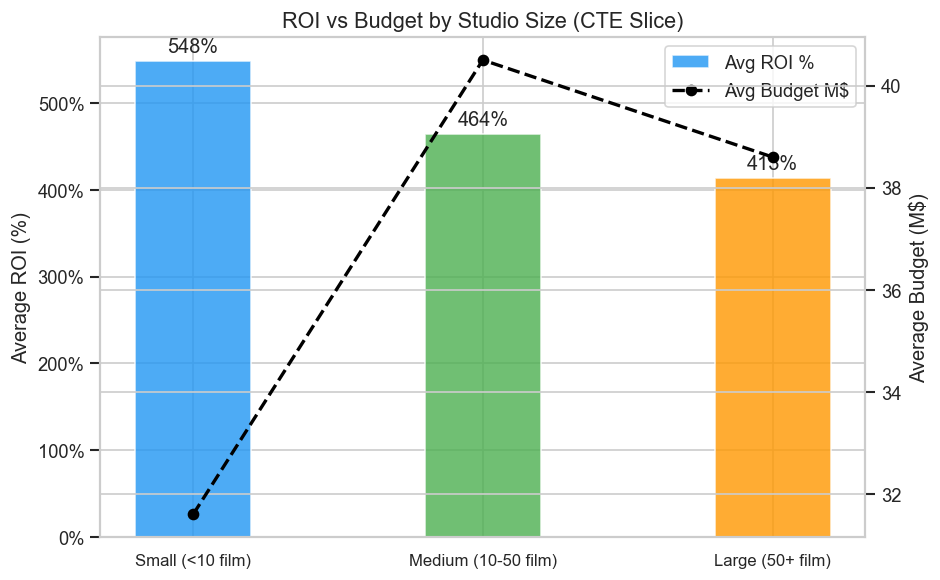

In [5]:
q4 = pd.read_csv(EXPORTS / 'q4_roi_studio_size.csv')
order = ['Small (<10 film)', 'Medium (10-50 film)', 'Large (50+ film)']
q4['size_band'] = pd.Categorical(q4['size_band'], categories=order, ordered=True)
q4 = q4.sort_values('size_band')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
x = range(len(q4))
bars4 = ax1.bar(x, q4['avg_roi_pct'], width=0.4, color=['#2196F3','#4CAF50','#FF9800'],
                label='Avg ROI %', alpha=0.8)
ax2.plot(x, q4['avg_budget_m'], 'k--o', linewidth=2, label='Avg Budget M$')
ax1.set_xticks(list(x))
ax1.set_xticklabels(q4['size_band'], fontsize=10)
ax1.set_ylabel('Average ROI (%)')
ax2.set_ylabel('Average Budget (M$)')
ax1.set_title('ROI vs Budget by Studio Size (CTE Slice)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}%'))
ax1.bar_label(bars4, labels=[f'{v:,.0f}%' for v in q4['avg_roi_pct']], padding=3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig(EXPORTS / 'plot_q4_roi_studio_size.png', bbox_inches='tight')
plt.show()


## Q5 — Distribuzione del ROI per quartile di budget (NTILE window)
La popolazione include ogni film distinto con ROI disponibile. Media e mediana sono confrontate insieme; massimo e conteggio sopra il fence `Q3 + 1.5 × IQR` mostrano quanto gli estremi influenzino la media.

**Insight calcolato dall'export**: la media supera la mediana in **4/4 quartili**. Il divario assoluto maggiore è in **Q1** (media 2,092,053.9% vs mediana 218.8%), coerente con una distribuzione asimmetrica. Il fence alto 1.5×IQR identifica **395** film; il massimo osservato è 1,239,638,200.0% in Q1. Il rating medio usa **5,183/5,194** film con rating.

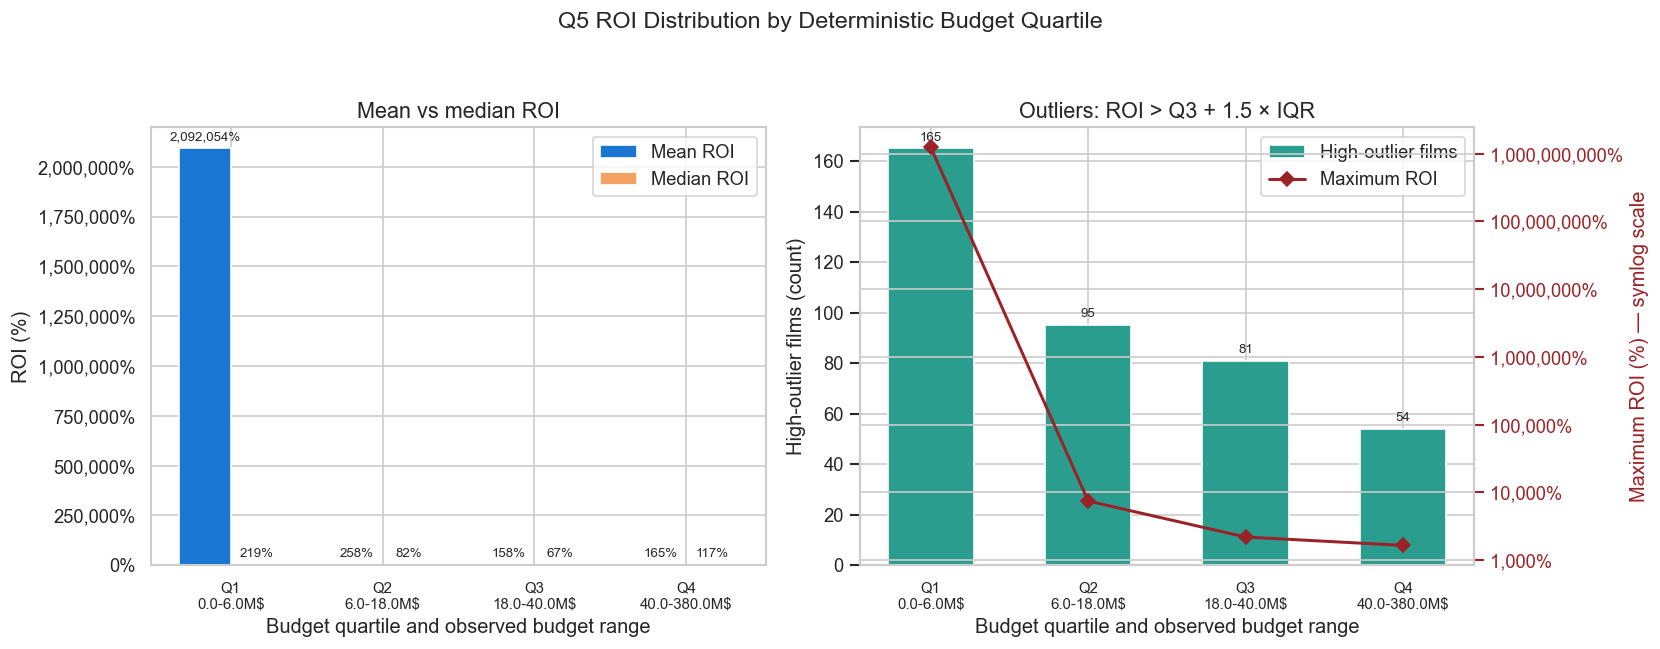

In [6]:
q5 = pd.read_csv(EXPORTS / 'q5_budget_quartile_rating.csv').sort_values('budget_quartile')
labels5 = [
    f'Q{int(row.budget_quartile)}\n{row.min_budget_m:.1f}-{row.max_budget_m:.1f}M$'
    for _, row in q5.iterrows()
]
q5['mean_median_gap'] = q5['mean_roi_pct'] - q5['median_roi_pct']
widest_gap_q5 = q5.loc[q5['mean_median_gap'].abs().idxmax()]
largest_max_q5 = q5.loc[q5['max_roi_pct'].idxmax()]
rated_films_q5 = int(q5['num_rated_films'].sum())
all_films_q5 = int(q5['num_films'].sum())
outliers_q5 = int(q5['high_outlier_count'].sum())
mean_above_median_q5 = int(q5['mean_roi_pct'].gt(q5['median_roi_pct']).sum())
display(Markdown(
    f"**Insight calcolato dall'export**: la media supera la mediana in "
    f"**{mean_above_median_q5}/{len(q5)} quartili**. Il divario assoluto maggiore è in "
    f"**Q{int(widest_gap_q5['budget_quartile'])}** "
    f"(media {widest_gap_q5['mean_roi_pct']:,.1f}% vs mediana "
    f"{widest_gap_q5['median_roi_pct']:,.1f}%), coerente con una distribuzione asimmetrica. "
    f"Il fence alto 1.5×IQR identifica **{outliers_q5:,}** film; il massimo osservato è "
    f"{largest_max_q5['max_roi_pct']:,.1f}% in Q{int(largest_max_q5['budget_quartile'])}. "
    f"Il rating medio usa **{rated_films_q5:,}/{all_films_q5:,}** film con rating."
))

fig, (ax5_roi, ax5_outliers) = plt.subplots(1, 2, figsize=(14, 5.5))
x5 = list(range(len(q5)))
width5 = 0.34
mean_bars5 = ax5_roi.bar(
    [value - width5 / 2 for value in x5], q5['mean_roi_pct'], width5,
    label='Mean ROI', color='#1976D2'
)
median_bars5 = ax5_roi.bar(
    [value + width5 / 2 for value in x5], q5['median_roi_pct'], width5,
    label='Median ROI', color='#F4A261'
)
ax5_roi.set_xticks(x5, labels5, fontsize=9)
ax5_roi.set_xlabel('Budget quartile and observed budget range')
ax5_roi.set_ylabel('ROI (%)')
ax5_roi.set_title('Mean vs median ROI')
ax5_roi.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value:,.0f}%'))
ax5_roi.bar_label(
    mean_bars5, labels=[f'{value:,.0f}%' for value in q5['mean_roi_pct']],
    padding=3, fontsize=8
)
ax5_roi.bar_label(
    median_bars5, labels=[f'{value:,.0f}%' for value in q5['median_roi_pct']],
    padding=3, fontsize=8
)
ax5_roi.legend()

outlier_bars5 = ax5_outliers.bar(
    x5, q5['high_outlier_count'], width=0.55, color='#2A9D8F',
    label='High-outlier films'
)
ax5_outliers.set_xticks(x5, labels5, fontsize=9)
ax5_outliers.set_xlabel('Budget quartile and observed budget range')
ax5_outliers.set_ylabel('High-outlier films (count)')
ax5_outliers.set_title('Outliers: ROI > Q3 + 1.5 × IQR')
ax5_outliers.bar_label(
    outlier_bars5, labels=[f'{int(value):,}' for value in q5['high_outlier_count']],
    padding=3, fontsize=8
)
max_axis5 = ax5_outliers.twinx()
max_line5 = max_axis5.plot(
    x5, q5['max_roi_pct'], color='#9B2226', marker='D', linewidth=1.8,
    label='Maximum ROI'
)[0]
max_axis5.set_ylabel('Maximum ROI (%) — symlog scale', color='#9B2226')
max_axis5.set_yscale('symlog', linthresh=100)
max_axis5.tick_params(axis='y', colors='#9B2226')
max_axis5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value:,.0f}%'))
ax5_outliers.legend(
    [outlier_bars5, max_line5], ['High-outlier films', 'Maximum ROI'], loc='upper right'
)
fig.suptitle('Q5 ROI Distribution by Deterministic Budget Quartile', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(EXPORTS / 'plot_q5_budget_quartile_rating.png', bbox_inches='tight')
plt.show()


## Q6 — Revenue cumulativo per genere (SUM OVER PARTITION BY — BONUS)
**Insight (risultati OLAP)**: nei 2010s Adventure guida il cumulato con 231,52 B$, seguita da Action (215,03 B$); Comedy (178,45 B$) precede di poco Drama (175,61 B$). Le linee indipendenti mostrano i cumulati prodotti da SQL senza sommarli nuovamente tra generi.

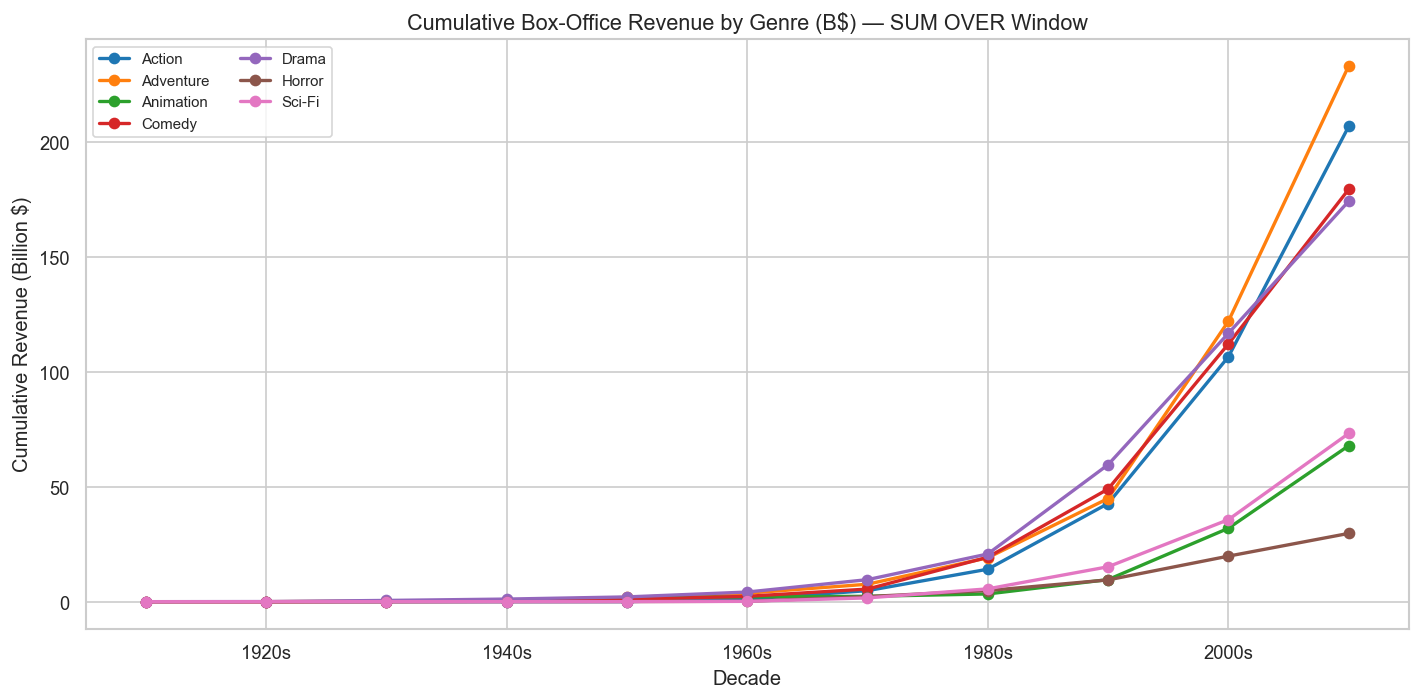

In [7]:
q6 = pd.read_csv(EXPORTS / 'q6_cumulative_revenue_genre.csv')
pivot6 = q6.pivot(index='decade', columns='genre_name', values='cumulative_revenue_b').ffill()

fig, ax = plt.subplots(figsize=(12, 6))
for genre in pivot6.columns:
    ax.plot(pivot6.index, pivot6[genre], marker='o', linewidth=2, label=genre)
ax.set_title('Cumulative Box-Office Revenue by Genre (B$) — SUM OVER Window')
ax.set_xlabel('Decade')
ax.set_ylabel('Cumulative Revenue (Billion $)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(EXPORTS / 'plot_q6_cumulative_revenue.png', bbox_inches='tight')
plt.show()


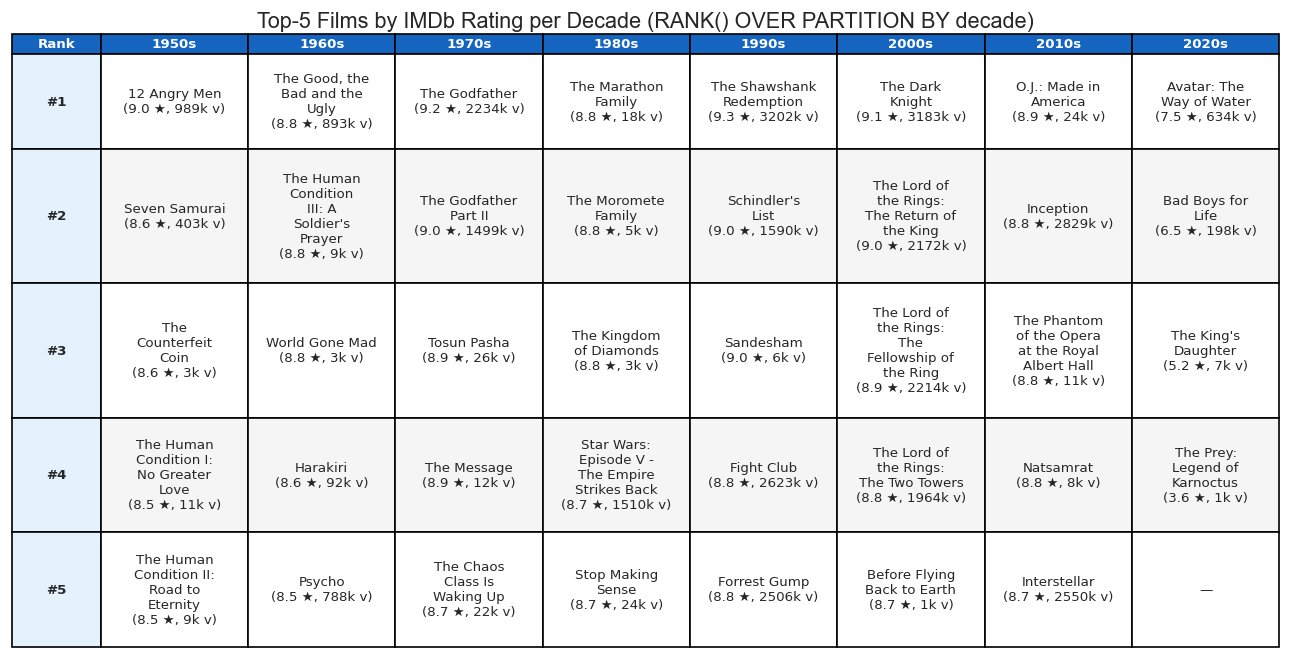

In [8]:
q7 = pd.read_csv(EXPORTS / 'q7_top_films_by_decade.csv')

def _wrap(t, w=14):
    if len(t) <= w: return t
    s = t[:w]
    i = s.rfind(' ')
    if i > 0:
        return t[:i] + '\n' + _wrap(t[i+1:], w)
    else:
        return t[:w] + '\n' + _wrap(t[w:], w)


decades = sorted(q7['decade'].unique())
col_labels = ['Rank'] + [f"{int(d)}s" for d in decades]
table_data = []
row_line_counts = [1]
for rank in range(1, 6):
    row = [f'#{rank}']
    for decade in decades:
        cell = q7[(q7['decade'] == decade) & (q7['rank_in_decade'] == rank)]
        if len(cell) > 0:
            title = cell.iloc[0]['film_title']
            rating = cell.iloc[0]['avg_rating']
            votes_k = cell.iloc[0]['num_votes'] / 1000
            row.append(f"{_wrap(title)}\n({rating} ★, {votes_k:.0f}k v)")
        else:
            row.append('—')
    table_data.append(row)
    row_line_counts.append(max(text.count('\n') + 1 for text in row))

row_weights = [1.0] + [lines + 0.7 for lines in row_line_counts[1:]]
row_heights = [weight / sum(row_weights) for weight in row_weights]
fig_height = max(5.0, 0.18 * sum(row_weights))

fig, ax = plt.subplots(figsize=(11, fig_height))
ax.axis('off')

col_widths = [0.07] + [0.93 / len(decades)] * len(decades)
tbl = ax.table(cellText=table_data, colLabels=col_labels,
               colWidths=col_widths, bbox=[0, 0, 1, 1], cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_height(row_heights[r])
    cell.PAD = 0.03
    cell.set_text_props(fontfamily='DejaVu Sans')
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#E3F2FD')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#F5F5F5' if r % 2 == 0 else 'white')

ax.set_title('Top-5 Films by IMDb Rating per Decade (RANK() OVER PARTITION BY decade)',
             pad=4)
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.02)
plt.savefig(EXPORTS / 'plot_q7_top_films_decade.png', bbox_inches='tight', dpi=150)
plt.show()

## Q7 — Top-5 film per rating in ogni decade (RANK() Window — BONUS)
**Insight**: Nelle decadi recenti il volume di voti è molto più alto (The Shawshank Redemption: 3.2M voti). Nelle decadi pre-1970 i cult classici raggiungono rating altissimi con pochi votanti, testimoniando il bias temporale di IMDb: l'audience online vota prevalentemente film moderni.